# 🛒 Project: Customer Segmentation

---

## End-to-End Unsupervised Learning Project

Welcome to your **Customer Segmentation** project! In this lab, you will:

1. Load and explore customer data
2. Clean and prepare data for ML
3. Find optimal number of clusters
4. Apply K-Means clustering
5. Visualize clusters with PCA
6. Analyze and name customer segments
7. Create business recommendations

---

## Real-World Context:

This is exactly what data scientists at **Amazon**, **Netflix**, **Spotify**, and **banks** do to understand their customers and personalize marketing!

---

## Instructions:

**Run each cell one by one** by pressing **Shift + Enter**

Read the explanations carefully to understand each step!

---

# PART 1: Setup and Data Loading

First, let's import all the libraries we need.

In [123]:
# Import pandas for data handling
import pandas as pd
print("✓ pandas loaded!")

✓ pandas loaded!


In [125]:
# Import numpy for math operations
import numpy as np
print("✓ numpy loaded!")

✓ numpy loaded!


In [127]:
# Import matplotlib for visualizations
import matplotlib.pyplot as plt
print("✓ matplotlib loaded!")

✓ matplotlib loaded!


In [129]:
# Import seaborn for better looking charts
import seaborn as sns
print("✓ seaborn loaded!")

✓ seaborn loaded!


In [131]:
# Import K-Means clustering
from sklearn.cluster import KMeans
print("✓ KMeans loaded!")

✓ KMeans loaded!


In [133]:
# Import StandardScaler for data preparation
from sklearn.preprocessing import StandardScaler
print("✓ StandardScaler loaded!")

✓ StandardScaler loaded!


In [135]:
# Import PCA for visualization
from sklearn.decomposition import PCA
print("✓ PCA loaded!")

✓ PCA loaded!


In [137]:
# Import silhouette score for cluster evaluation
from sklearn.metrics import silhouette_score
print("✓ silhouette_score loaded!")

✓ silhouette_score loaded!


In [139]:
# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

print("="*50)
print("ALL LIBRARIES READY!")
print("="*50)

ALL LIBRARIES READY!


---

## Load the Customer Dataset

We have customer data with:
- **CustomerID**: Unique customer identifier
- **Age**: Customer's age
- **Annual Income**: Yearly income in thousands ($k)
- **Spending Score**: Score 1-100 based on spending behavior

In [142]:
# Create the customer dataset
# This simulates real mall customer data

data = {
    'CustomerID': list(range(1, 201)),
    'Age': [19, 21, 20, 23, 31, 22, 35, 23, 64, 30, 67, 35, 58, 24, 37, 22, 35, 20, 52, 35,
            35, 25, 46, 31, 54, 29, 45, 35, 40, 23, 60, 21, 53, 18, 49, 21, 42, 30, 36, 20,
            65, 24, 48, 31, 49, 24, 50, 27, 29, 31, 49, 33, 31, 59, 50, 47, 51, 69, 27, 53,
            70, 19, 67, 54, 63, 18, 43, 68, 19, 32, 70, 47, 60, 60, 59, 26, 45, 40, 23, 49,
            57, 38, 67, 46, 21, 48, 55, 22, 34, 50, 68, 18, 48, 40, 32, 24, 47, 27, 48, 20,
            23, 49, 67, 26, 49, 21, 66, 54, 68, 66, 65, 19, 38, 19, 18, 19, 63, 49, 51, 50,
            27, 38, 40, 39, 23, 31, 43, 40, 59, 38, 47, 39, 25, 31, 20, 29, 44, 32, 19, 35,
            57, 32, 28, 32, 25, 28, 48, 32, 34, 34, 43, 39, 44, 38, 47, 27, 37, 30, 34, 30,
            56, 29, 19, 31, 50, 36, 42, 33, 36, 32, 40, 28, 36, 36, 52, 30, 58, 27, 59, 35,
            37, 32, 46, 29, 41, 30, 54, 28, 41, 36, 34, 32, 33, 38, 47, 35, 45, 32, 32, 30],
    'Annual_Income_k': [15, 15, 16, 16, 17, 17, 18, 18, 19, 19, 19, 19, 20, 20, 20, 20, 21, 21, 23, 23,
                        24, 24, 25, 25, 28, 28, 28, 28, 29, 29, 30, 30, 33, 33, 33, 33, 34, 34, 37, 37,
                        38, 38, 39, 39, 39, 39, 40, 40, 40, 40, 42, 42, 43, 43, 43, 43, 44, 44, 46, 46,
                        46, 46, 47, 47, 48, 48, 48, 48, 48, 48, 49, 49, 50, 50, 54, 54, 54, 54, 54, 54,
                        57, 57, 58, 58, 59, 59, 60, 60, 61, 61, 62, 62, 62, 62, 63, 63, 64, 64, 65, 65,
                        69, 69, 70, 70, 71, 71, 71, 71, 72, 72, 73, 73, 74, 74, 75, 75, 76, 76, 77, 77,
                        78, 78, 78, 78, 78, 78, 78, 78, 79, 79, 81, 81, 85, 85, 86, 86, 87, 87, 87, 87,
                        87, 87, 88, 88, 88, 88, 93, 93, 97, 97, 98, 98, 99, 99, 101, 101, 103, 103, 103, 103,
                        113, 113, 120, 120, 126, 126, 137, 137, 137, 137, 78, 78, 77, 77, 77, 77, 102, 102, 85, 85,
                        90, 90, 75, 75, 80, 80, 88, 88, 92, 92, 94, 94, 95, 95, 99, 99, 105, 105, 110, 110],
    'Spending_Score': [39, 81, 6, 77, 40, 76, 6, 94, 3, 72, 14, 99, 15, 77, 13, 79, 35, 66, 29, 98,
                       35, 73, 5, 73, 14, 82, 32, 61, 31, 87, 4, 73, 4, 92, 14, 81, 17, 73, 26, 75,
                       35, 92, 36, 61, 28, 65, 55, 47, 42, 42, 52, 60, 54, 60, 45, 41, 50, 46, 51, 46,
                       56, 55, 52, 59, 51, 59, 50, 48, 59, 47, 55, 42, 49, 56, 47, 54, 53, 48, 52, 42,
                       51, 55, 41, 44, 57, 46, 58, 55, 60, 46, 55, 41, 49, 40, 42, 52, 47, 50, 42, 49,
                       41, 48, 59, 55, 56, 42, 50, 46, 43, 48, 52, 54, 42, 46, 48, 50, 43, 59, 43, 57,
                       56, 40, 58, 91, 29, 77, 35, 95, 11, 75, 9, 75, 34, 71, 5, 88, 7, 73, 10, 72,
                       5, 93, 40, 87, 12, 97, 36, 74, 22, 90, 17, 88, 20, 76, 16, 89, 1, 78, 1, 73,
                       35, 83, 5, 93, 26, 75, 20, 95, 27, 63, 13, 75, 10, 92, 13, 86, 15, 69, 14, 90,
                       32, 86, 15, 88, 39, 97, 24, 68, 17, 85, 23, 69, 8, 91, 16, 79, 28, 74, 18, 83]
}

df = pd.DataFrame(data)
print("Dataset created with", len(df), "customers!")

Dataset created with 200 customers!


In [144]:
# Display first 10 rows
print("First 10 Customers:")
df.head(10)

First 10 Customers:


,CustomerID,Age,Annual_Income_k,Spending_Score
0,1,19,15,39
1,2,21,15,81
2,3,20,16,6
3,4,23,16,77
4,5,31,17,40
5,6,22,17,76
6,7,35,18,6
7,8,23,18,94
8,9,64,19,3
9,10,30,19,72


In [146]:
# Check the shape of data
print(f"Dataset shape: {df.shape}")
print(f"Number of customers: {df.shape[0]}")
print(f"Number of features: {df.shape[1]}")

Dataset shape: (200, 4)
Number of customers: 200
Number of features: 4


In [148]:
# Check data types
print("Data types:")
print(df.dtypes)

Data types:
CustomerID         int64
Age                int64
Annual_Income_k    int64
Spending_Score     int64
dtype: object


In [150]:
# Check for missing values
print("Missing values:")
print(df.isnull().sum())
print("\n✓ No missing values - data is clean!")

Missing values:
CustomerID         0
Age                0
Annual_Income_k    0
Spending_Score     0
dtype: int64

✓ No missing values - data is clean!


---

# PART 2: Exploratory Data Analysis (EDA)

Let's understand our data before clustering!

In [155]:
# Get basic statistics
print("Statistical Summary:")
df.describe()

Statistical Summary:


,CustomerID,Age,Annual_Income_k,Spending_Score
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,64.940000,50.200000
std,57.879185,13.969007,29.353099,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,67.000000,50.000000
75%,150.250000,49.000000,87.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [157]:
# What do the statistics tell us?
print("\n" + "="*50)
print("KEY INSIGHTS FROM STATISTICS")
print("="*50)

print(f"\nAGE:")
print(f"  • Range: {df['Age'].min()} to {df['Age'].max()} years")
print(f"  • Average: {df['Age'].mean():.1f} years")

print(f"\nANNUAL INCOME:")
print(f"  • Range: ${df['Annual_Income_k'].min()}k to ${df['Annual_Income_k'].max()}k")
print(f"  • Average: ${df['Annual_Income_k'].mean():.1f}k")

print(f"\nSPENDING SCORE:")
print(f"  • Range: {df['Spending_Score'].min()} to {df['Spending_Score'].max()}")
print(f"  • Average: {df['Spending_Score'].mean():.1f}")


KEY INSIGHTS FROM STATISTICS

AGE:
  • Range: 18 to 70 years
  • Average: 38.9 years

ANNUAL INCOME:
  • Range: $15k to $137k
  • Average: $64.9k

SPENDING SCORE:
  • Range: 1 to 99
  • Average: 50.2


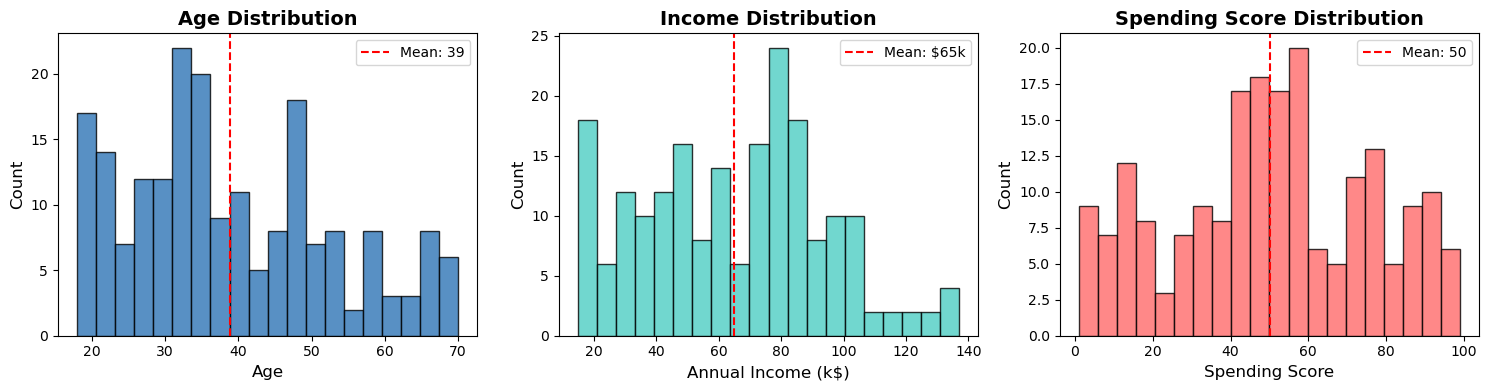


Observation: All features show varied distributions - good for clustering!


In [159]:
# Create figure for distributions
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Age distribution
axes[0].hist(df['Age'], bins=20, color='#2E75B6', edgecolor='black', alpha=0.8)
axes[0].set_xlabel('Age', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].set_title('Age Distribution', fontsize=14, fontweight='bold')
axes[0].axvline(df['Age'].mean(), color='red', linestyle='--', label=f"Mean: {df['Age'].mean():.0f}")
axes[0].legend()

# Income distribution  
axes[1].hist(df['Annual_Income_k'], bins=20, color='#4ECDC4', edgecolor='black', alpha=0.8)
axes[1].set_xlabel('Annual Income (k$)', fontsize=12)
axes[1].set_ylabel('Count', fontsize=12)
axes[1].set_title('Income Distribution', fontsize=14, fontweight='bold')
axes[1].axvline(df['Annual_Income_k'].mean(), color='red', linestyle='--', label=f"Mean: ${df['Annual_Income_k'].mean():.0f}k")
axes[1].legend()

# Spending Score distribution
axes[2].hist(df['Spending_Score'], bins=20, color='#FF6B6B', edgecolor='black', alpha=0.8)
axes[2].set_xlabel('Spending Score', fontsize=12)
axes[2].set_ylabel('Count', fontsize=12)
axes[2].set_title('Spending Score Distribution', fontsize=14, fontweight='bold')
axes[2].axvline(df['Spending_Score'].mean(), color='red', linestyle='--', label=f"Mean: {df['Spending_Score'].mean():.0f}")
axes[2].legend()

plt.tight_layout()
plt.show()

print("\nObservation: All features show varied distributions - good for clustering!")

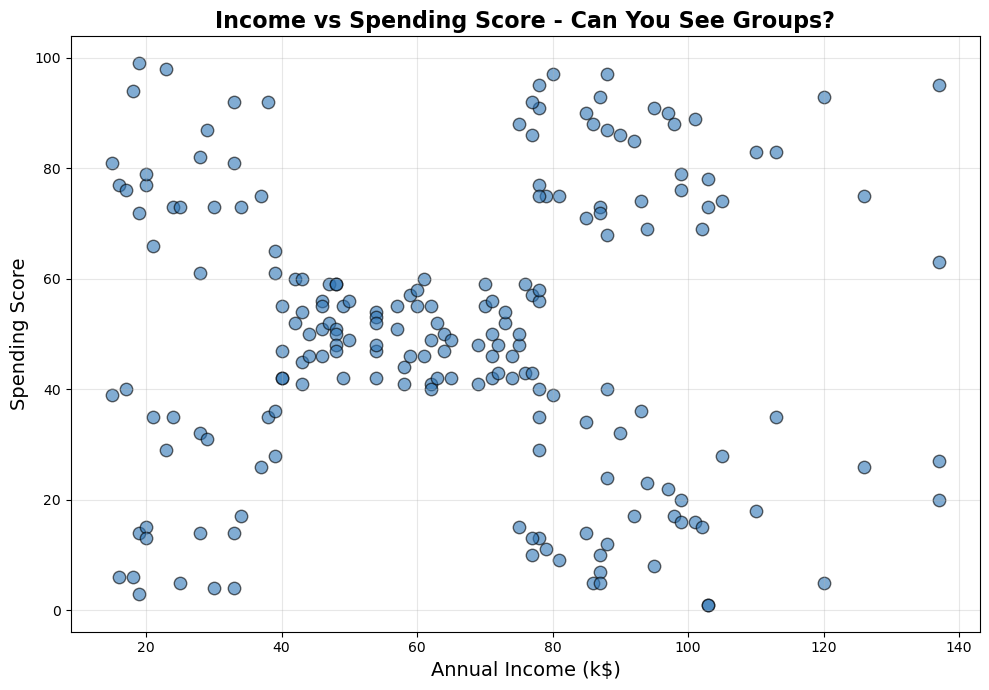


🔍 Look at the chart - can you spot natural groups?
   There appear to be about 5 clusters!


In [161]:
# Scatter plot: Income vs Spending Score
plt.figure(figsize=(10, 7))

plt.scatter(df['Annual_Income_k'], df['Spending_Score'], 
           c='#2E75B6', s=80, alpha=0.6, edgecolors='black')

plt.xlabel('Annual Income (k$)', fontsize=14)
plt.ylabel('Spending Score', fontsize=14)
plt.title('Income vs Spending Score - Can You See Groups?', fontsize=16, fontweight='bold')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n🔍 Look at the chart - can you spot natural groups?")
print("   There appear to be about 5 clusters!")

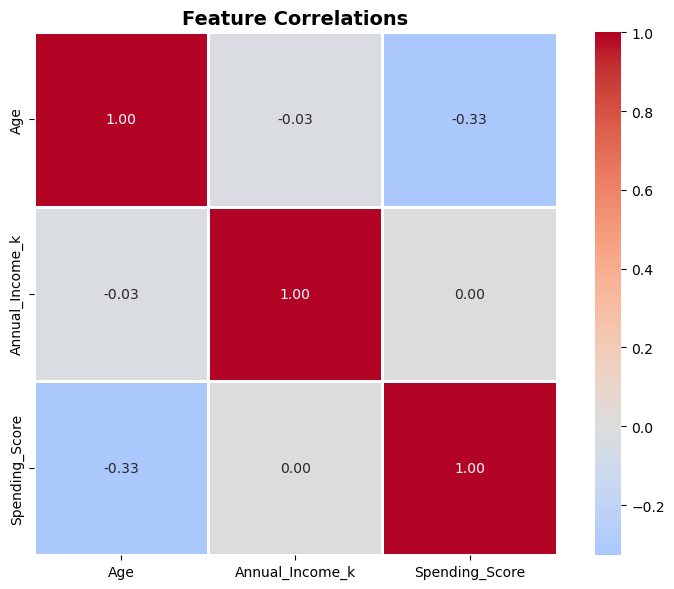


Insight: Features are not highly correlated - each provides unique information!


In [25]:
# Correlation heatmap
plt.figure(figsize=(8, 6))

# Select only numeric columns for correlation
numeric_cols = ['Age', 'Annual_Income_k', 'Spending_Score']
correlation = df[numeric_cols].corr()

sns.heatmap(correlation, annot=True, cmap='coolwarm', center=0,
           fmt='.2f', linewidths=2, square=True)

plt.title('Feature Correlations', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nInsight: Features are not highly correlated - each provides unique information!")

---

# PART 3: Data Preprocessing

Before clustering, we need to:
1. Select features for clustering
2. Scale the data (very important!)

In [164]:
# Select features for clustering
# We use Income and Spending Score (not CustomerID or Age for this analysis)

X = df[['Annual_Income_k', 'Spending_Score']]

print("Selected features:")
print("  1. Annual_Income_k")
print("  2. Spending_Score")
print(f"\nShape: {X.shape}")

Selected features:
  1. Annual_Income_k
  2. Spending_Score

Shape: (200, 2)


In [166]:
# Check the range of each feature
print("Feature ranges BEFORE scaling:")
print(f"  Income: {X['Annual_Income_k'].min()} to {X['Annual_Income_k'].max()}")
print(f"  Spending: {X['Spending_Score'].min()} to {X['Spending_Score'].max()}")

print("\n⚠️ Problem: Income has larger values, so it would dominate clustering!")

Feature ranges BEFORE scaling:
  Income: 15 to 137
  Spending: 1 to 99

⚠️ Problem: Income has larger values, so it would dominate clustering!


In [168]:
# Create the scaler
scaler = StandardScaler()
print("StandardScaler created!")

StandardScaler created!


In [170]:
# Scale the features
X_scaled = scaler.fit_transform(X)

print("Data scaled!")
print(f"Shape: {X_scaled.shape}")

Data scaled!
Shape: (200, 2)


In [172]:
# Verify scaling worked
print("Feature ranges AFTER scaling:")
print(f"  Income: {X_scaled[:, 0].min():.2f} to {X_scaled[:, 0].max():.2f}")
print(f"  Spending: {X_scaled[:, 1].min():.2f} to {X_scaled[:, 1].max():.2f}")

print("\n✓ Now both features are on the same scale!")

Feature ranges AFTER scaling:
  Income: -1.71 to 2.46
  Spending: -1.91 to 1.89

✓ Now both features are on the same scale!


---

# PART 4: Finding the Optimal Number of Clusters (K)

We don't know how many customer segments exist. We'll use two methods:
1. **Elbow Method** - looks at inertia (within-cluster sum of squares)
2. **Silhouette Score** - measures how similar points are to their own cluster

In [175]:
# Test different values of K (from 2 to 10)
k_range = range(2, 11)
print(f"Testing K values: {list(k_range)}")

Testing K values: [2, 3, 4, 5, 6, 7, 8, 9, 10]


In [177]:
# Calculate inertia for each K (for Elbow method)
inertias = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)
    print(f"K={k}: Inertia = {kmeans.inertia_:.2f}")

K=2: Inertia = 257.64
K=3: Inertia = 154.70
K=4: Inertia = 106.32
K=5: Inertia = 62.97
K=6: Inertia = 51.12
K=7: Inertia = 43.77
K=8: Inertia = 36.87
K=9: Inertia = 32.06
K=10: Inertia = 29.25


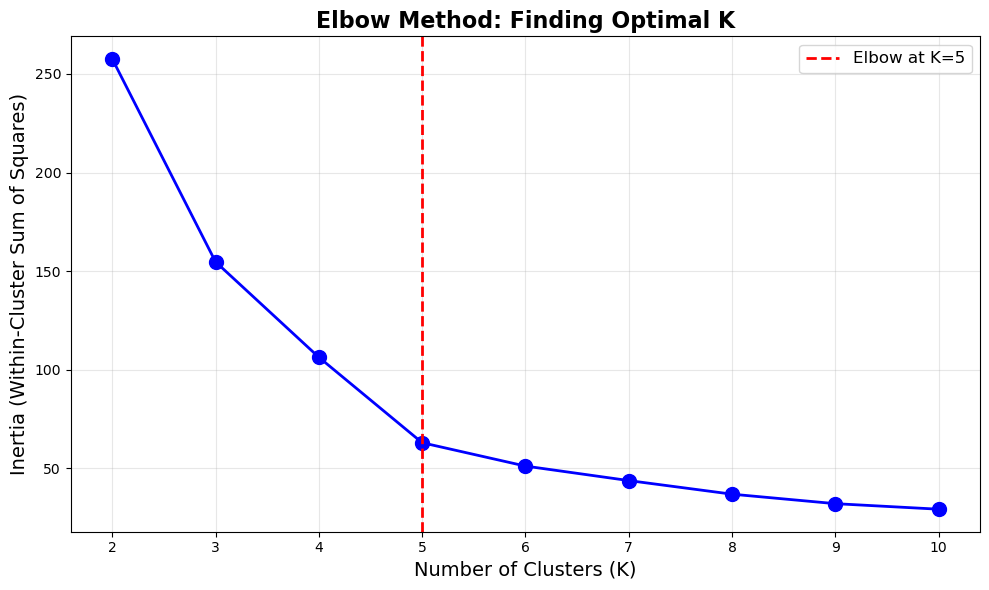


📍 The 'elbow' is at K=5 - inertia drops sharply until 5, then slows down!


In [179]:
# Plot the Elbow curve
plt.figure(figsize=(10, 6))

plt.plot(list(k_range), inertias, 'bo-', linewidth=2, markersize=10)
plt.axvline(x=5, color='red', linestyle='--', linewidth=2, label='Elbow at K=5')

plt.xlabel('Number of Clusters (K)', fontsize=14)
plt.ylabel('Inertia (Within-Cluster Sum of Squares)', fontsize=14)
plt.title('Elbow Method: Finding Optimal K', fontsize=16, fontweight='bold')
plt.xticks(list(k_range))
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n📍 The 'elbow' is at K=5 - inertia drops sharply until 5, then slows down!")

In [181]:
# Calculate Silhouette scores
silhouette_scores = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)
    print(f"K={k}: Silhouette Score = {score:.4f}")

K=2: Silhouette Score = 0.3390
K=3: Silhouette Score = 0.4536
K=4: Silhouette Score = 0.4830
K=5: Silhouette Score = 0.5443
K=6: Silhouette Score = 0.4849
K=7: Silhouette Score = 0.4596
K=8: Silhouette Score = 0.4518
K=9: Silhouette Score = 0.4542
K=10: Silhouette Score = 0.4524


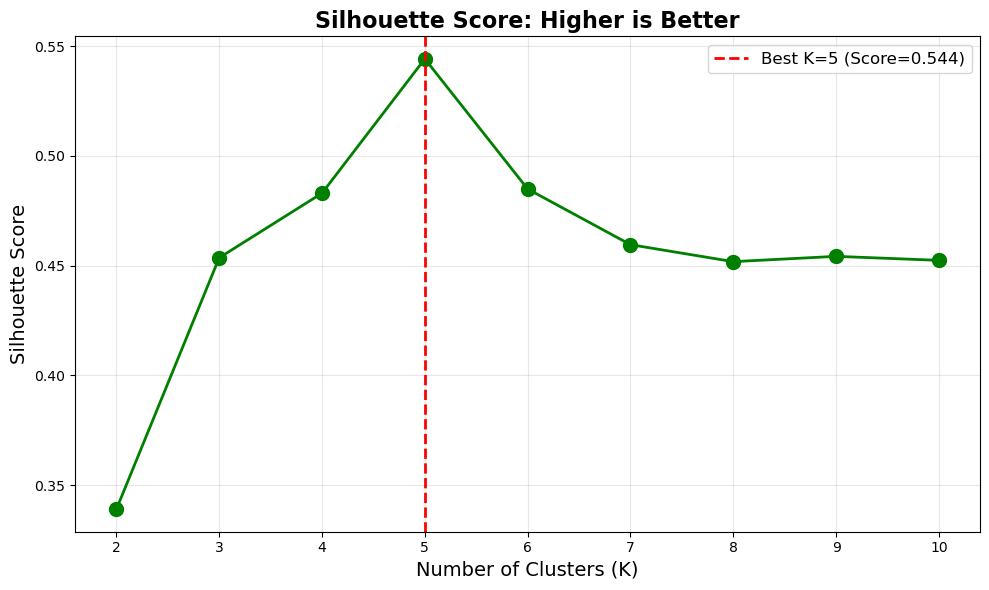


📍 Best Silhouette Score at K=5!


In [183]:
# Plot Silhouette scores
plt.figure(figsize=(10, 6))

plt.plot(list(k_range), silhouette_scores, 'go-', linewidth=2, markersize=10)

# Mark the best K
best_k = list(k_range)[np.argmax(silhouette_scores)]
best_score = max(silhouette_scores)
plt.axvline(x=best_k, color='red', linestyle='--', linewidth=2, 
           label=f'Best K={best_k} (Score={best_score:.3f})')

plt.xlabel('Number of Clusters (K)', fontsize=14)
plt.ylabel('Silhouette Score', fontsize=14)
plt.title('Silhouette Score: Higher is Better', fontsize=16, fontweight='bold')
plt.xticks(list(k_range))
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n📍 Best Silhouette Score at K={best_k}!")

In [185]:
# Conclusion
print("\n" + "="*50)
print("CONCLUSION: OPTIMAL K")
print("="*50)
print("\n• Elbow method suggests: K = 5")
print(f"• Silhouette score best at: K = {best_k}")
print("\n→ We will use K = 5 clusters!")
print("="*50)


CONCLUSION: OPTIMAL K

• Elbow method suggests: K = 5
• Silhouette score best at: K = 5

→ We will use K = 5 clusters!


---

# PART 5: Apply K-Means Clustering

Now let's cluster our customers into 5 segments!

In [188]:
# Set K = 5
K = 5
print(f"Creating K-Means with {K} clusters...")

Creating K-Means with 5 clusters...


In [190]:
# Create KMeans model
kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
print("K-Means model created!")

K-Means model created!


In [192]:
# Fit and predict clusters
cluster_labels = kmeans.fit_predict(X_scaled)
print("Clustering complete!")
print(f"Labels shape: {cluster_labels.shape}")

Clustering complete!
Labels shape: (200,)


In [194]:
# See the unique cluster labels
print("Unique cluster labels:", np.unique(cluster_labels))

Unique cluster labels: [0 1 2 3 4]


In [196]:
# Add cluster labels to original dataframe
df['Cluster'] = cluster_labels
print("Cluster labels added to dataframe!")

Cluster labels added to dataframe!


In [198]:
# Count customers in each cluster
print("Customers per cluster:")
print(df['Cluster'].value_counts().sort_index())

Customers per cluster:
Cluster
0    23
1    80
2    36
3    39
4    22
Name: count, dtype: int64


In [200]:
# View sample customers from each cluster
print("\nSample customers from each cluster:")
for i in range(K):
    print(f"\n--- Cluster {i} ---")
    print(df[df['Cluster'] == i][['CustomerID', 'Age', 'Annual_Income_k', 'Spending_Score']].head(3))


Sample customers from each cluster:

--- Cluster 0 ---
   CustomerID  Age  Annual_Income_k  Spending_Score
0           1   19               15              39
2           3   20               16               6
4           5   31               17              40

--- Cluster 1 ---
    CustomerID  Age  Annual_Income_k  Spending_Score
43          44   31               39              61
46          47   50               40              55
47          48   27               40              47

--- Cluster 2 ---
     CustomerID  Age  Annual_Income_k  Spending_Score
124         125   23               78              29
128         129   59               79              11
130         131   47               81               9

--- Cluster 3 ---
     CustomerID  Age  Annual_Income_k  Spending_Score
123         124   39               78              91
125         126   31               78              77
127         128   40               78              95

--- Cluster 4 ---
   CustomerID  A

---

# PART 6: Visualize Clusters

Let's see our customer segments visually!

In [203]:
# Define colors for clusters
cluster_colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7']
print("Colors defined for 5 clusters!")

Colors defined for 5 clusters!


In [205]:
# Get cluster centers
centers = kmeans.cluster_centers_

# Transform centers back to original scale for display
centers_original = scaler.inverse_transform(centers)

print("Cluster Centers (Original Scale):")
print(f"{'Cluster':<10} {'Income (k$)':<15} {'Spending Score':<15}")
print("-"*40)
for i, center in enumerate(centers_original):
    print(f"{i:<10} {center[0]:<15.1f} {center[1]:<15.1f}")

Cluster Centers (Original Scale):
Cluster    Income (k$)     Spending Score 
----------------------------------------
0          26.3            20.9           
1          58.8            49.7           
2          95.6            17.6           
3          94.3            82.1           
4          25.7            79.4           


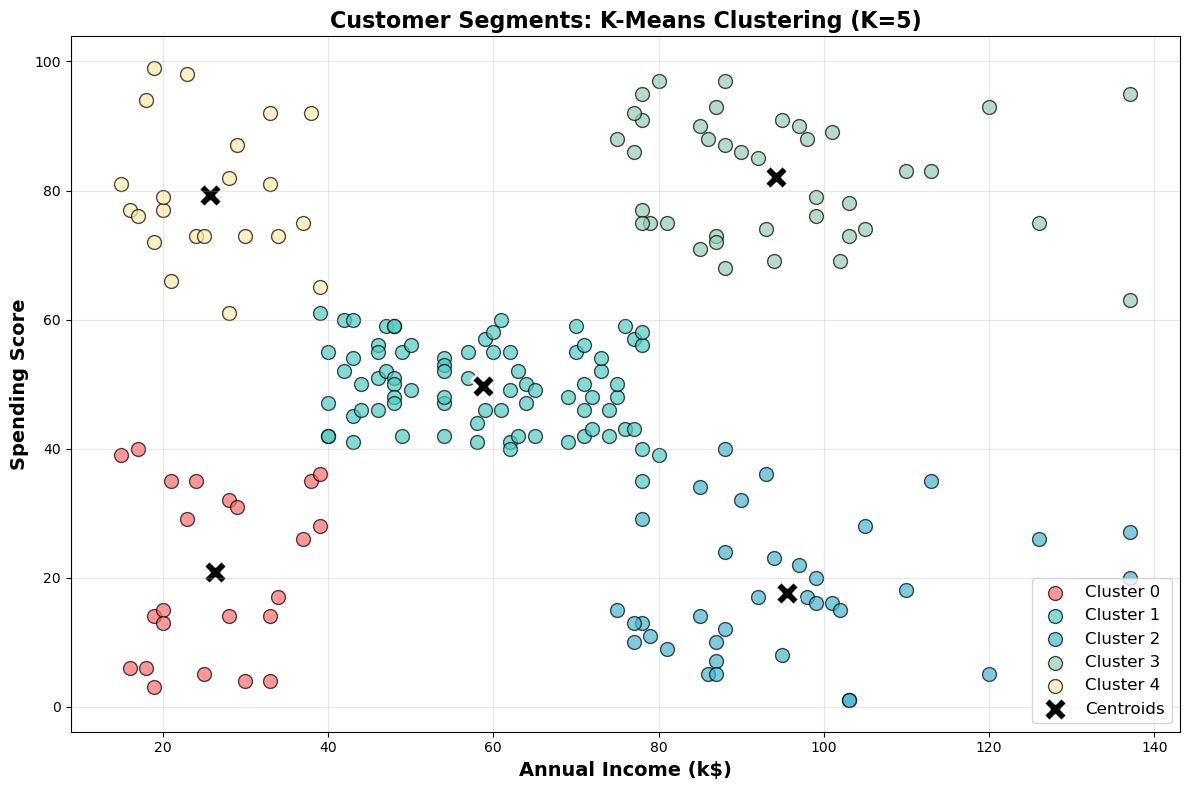


✓ 5 distinct customer segments identified!


In [207]:
# Visualize clusters with scatter plot
plt.figure(figsize=(12, 8))

# Plot each cluster
for i in range(K):
    cluster_data = df[df['Cluster'] == i]
    plt.scatter(cluster_data['Annual_Income_k'], 
               cluster_data['Spending_Score'],
               c=cluster_colors[i],
               label=f'Cluster {i}',
               s=100, alpha=0.7, edgecolors='black', linewidth=1)

# Plot cluster centers
plt.scatter(centers_original[:, 0], centers_original[:, 1],
           c='black', marker='X', s=300, label='Centroids', edgecolors='white', linewidth=2)

plt.xlabel('Annual Income (k$)', fontsize=14, fontweight='bold')
plt.ylabel('Spending Score', fontsize=14, fontweight='bold')
plt.title('Customer Segments: K-Means Clustering (K=5)', fontsize=16, fontweight='bold')
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✓ 5 distinct customer segments identified!")

---

# PART 7: Analyze Customer Segments

Now let's understand each segment and give them meaningful names!

In [210]:
# Calculate statistics for each cluster
cluster_stats = df.groupby('Cluster').agg({
    'Age': ['mean', 'min', 'max'],
    'Annual_Income_k': ['mean', 'min', 'max'],
    'Spending_Score': ['mean', 'min', 'max'],
    'CustomerID': 'count'
}).round(1)

print("Cluster Statistics:")
cluster_stats

Cluster Statistics:


Age         Annual_Income_k          Spending_Score          \
         mean min max            mean min  max           mean min max   
Cluster                                                                 
0        45.2  19  67            26.3  15   39           20.9   3  40   
1        43.1  18  70            58.8  39   80           49.7  35  61   
2        40.3  19  59            95.6  75  137           17.6   1  40   
3        32.7  27  40            94.3  75  137           82.1  63  97   
4        25.3  18  35            25.7  15   39           79.4  61  99   

        CustomerID  
             count  
Cluster             
0               23  
1               80  
2               36  
3               39  
4               22

In [212]:
# Create a cleaner summary table
summary = df.groupby('Cluster').agg({
    'CustomerID': 'count',
    'Age': 'mean',
    'Annual_Income_k': 'mean',
    'Spending_Score': 'mean'
}).round(1)

summary.columns = ['Count', 'Avg_Age', 'Avg_Income', 'Avg_Spending']
summary = summary.sort_values('Avg_Income')

print("\nCluster Summary (sorted by income):")
summary


Cluster Summary (sorted by income):


,Count,Avg_Age,Avg_Income,Avg_Spending
Cluster,,,,
4,22,25.3,25.7,79.4
0,23,45.2,26.3,20.9
1,80,43.1,58.8,49.7
3,39,32.7,94.3,82.1
2,36,40.3,95.6,17.6


In [214]:
# Name the segments based on their characteristics
segment_names = {}

for cluster in range(K):
    avg_income = df[df['Cluster'] == cluster]['Annual_Income_k'].mean()
    avg_spending = df[df['Cluster'] == cluster]['Spending_Score'].mean()
    
    # Determine income level
    if avg_income < 40:
        income_level = 'Low Income'
    elif avg_income < 70:
        income_level = 'Medium Income'
    else:
        income_level = 'High Income'
    
    # Determine spending level
    if avg_spending < 35:
        spending_level = 'Low Spenders'
    elif avg_spending < 65:
        spending_level = 'Moderate Spenders'
    else:
        spending_level = 'High Spenders'
    
    segment_names[cluster] = f"{income_level}, {spending_level}"

print("\nSegment Names:")
print("="*50)
for cluster, name in segment_names.items():
    count = len(df[df['Cluster'] == cluster])
    print(f"Cluster {cluster}: {name} ({count} customers)")


Segment Names:
Cluster 0: Low Income, Low Spenders (23 customers)
Cluster 1: Medium Income, Moderate Spenders (80 customers)
Cluster 2: High Income, Low Spenders (36 customers)
Cluster 3: High Income, High Spenders (39 customers)
Cluster 4: Low Income, High Spenders (22 customers)


In [216]:
# Add segment names to dataframe
df['Segment_Name'] = df['Cluster'].map(segment_names)
print("Segment names added to dataframe!")

Segment names added to dataframe!


In [218]:
# View final data
print("\nSample of final segmented data:")
df[['CustomerID', 'Age', 'Annual_Income_k', 'Spending_Score', 'Cluster', 'Segment_Name']].head(10)


Sample of final segmented data:


,CustomerID,Age,Annual_Income_k,Spending_Score,Cluster,Segment_Name
0,1,19,15,39,0,"Low Income, Low Spenders"
1,2,21,15,81,4,"Low Income, High Spenders"
2,3,20,16,6,0,"Low Income, Low Spenders"
3,4,23,16,77,4,"Low Income, High Spenders"
4,5,31,17,40,0,"Low Income, Low Spenders"
5,6,22,17,76,4,"Low Income, High Spenders"
6,7,35,18,6,0,"Low Income, Low Spenders"
7,8,23,18,94,4,"Low Income, High Spenders"
8,9,64,19,3,0,"Low Income, Low Spenders"
9,10,30,19,72,4,"Low Income, High Spenders"


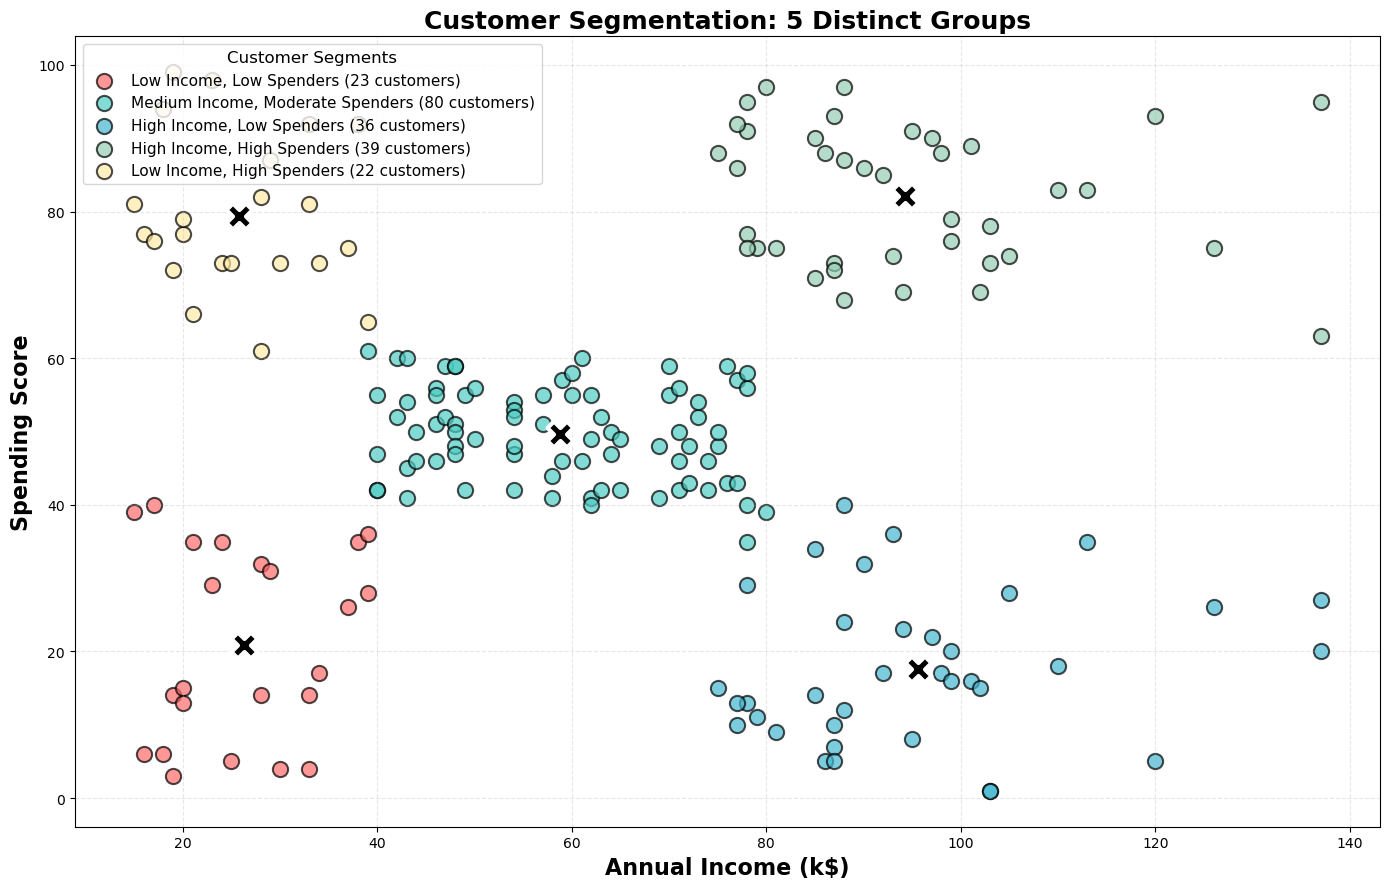

In [220]:
# Visualize with segment names
plt.figure(figsize=(14, 9))

for i in range(K):
    cluster_data = df[df['Cluster'] == i]
    plt.scatter(cluster_data['Annual_Income_k'], 
               cluster_data['Spending_Score'],
               c=cluster_colors[i],
               label=f'{segment_names[i]} ({len(cluster_data)} customers)',
               s=120, alpha=0.7, edgecolors='black', linewidth=1.5)

# Add cluster centers
plt.scatter(centers_original[:, 0], centers_original[:, 1],
           c='black', marker='X', s=350, edgecolors='white', linewidth=3, zorder=5)

plt.xlabel('Annual Income (k$)', fontsize=16, fontweight='bold')
plt.ylabel('Spending Score', fontsize=16, fontweight='bold')
plt.title('Customer Segmentation: 5 Distinct Groups', fontsize=18, fontweight='bold')
plt.legend(title='Customer Segments', fontsize=11, title_fontsize=12, loc='upper left')
plt.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

---

# PART 8: PCA Visualization

Let's also visualize using PCA for a different perspective!

In [223]:
# Apply PCA (though we only have 2 features, this shows the technique)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print(f"Explained variance: {pca.explained_variance_ratio_}")
print(f"Total variance captured: {sum(pca.explained_variance_ratio_)*100:.1f}%")

Explained variance: [0.5017747 0.4982253]
Total variance captured: 100.0%


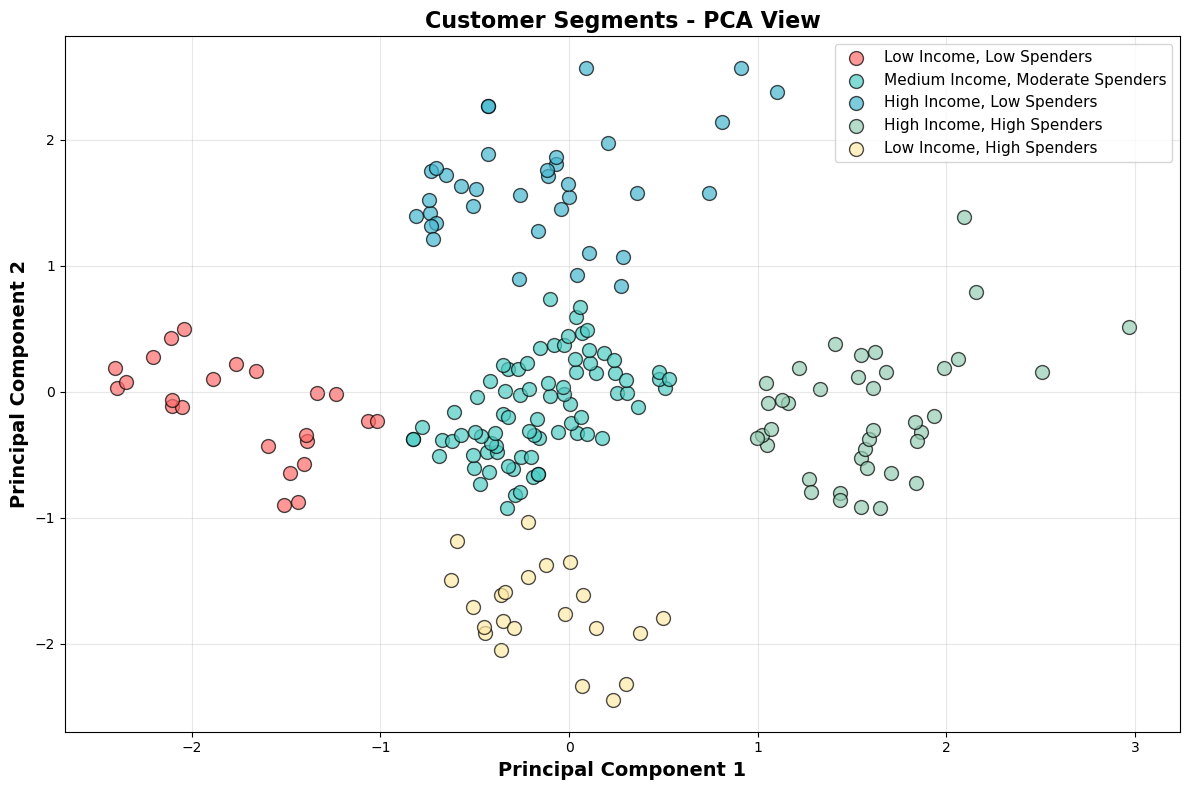

In [225]:
# PCA visualization
plt.figure(figsize=(12, 8))

for i in range(K):
    mask = cluster_labels == i
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=cluster_colors[i],
               label=segment_names[i],
               s=100, alpha=0.7, edgecolors='black', linewidth=1)

plt.xlabel('Principal Component 1', fontsize=14, fontweight='bold')
plt.ylabel('Principal Component 2', fontsize=14, fontweight='bold')
plt.title('Customer Segments - PCA View', fontsize=16, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---

# PART 9: Business Recommendations

Based on our analysis, let's create actionable recommendations!

In [230]:
# Create detailed analysis for each segment
print("="*70)
print("              BUSINESS RECOMMENDATIONS")
print("="*70)

for cluster in range(K):
    segment = df[df['Cluster'] == cluster]
    avg_income = segment['Annual_Income_k'].mean()
    avg_spending = segment['Spending_Score'].mean()
    count = len(segment)
    
    print(f"\n{'─'*70}")
    print(f"SEGMENT {cluster}: {segment_names[cluster].upper()}")
    print(f"{'─'*70}")
    print(f"  Customers: {count} ({count/len(df)*100:.1f}% of total)")
    print(f"  Avg Income: ${avg_income:.0f}k | Avg Spending Score: {avg_spending:.0f}")
    
    # Recommendations based on segment profile
    if avg_income >= 70 and avg_spending >= 60:
        print("\n  💎 PROFILE: VIP Customers - High Value, High Loyalty")
        print("  📌 STRATEGY:")
        print("     • Priority: RETAIN and EXPAND")
        print("     • Offer exclusive VIP membership programs")
        print("     • Early access to new products")
        print("     • Personal shopping assistant service")
        print("     • Premium loyalty rewards (2x points)")
    
    elif avg_income >= 70 and avg_spending < 40:
        print("\n  🎯 PROFILE: Potential Spenders - High Income, Low Engagement")
        print("  📌 STRATEGY:")
        print("     • Priority: ACTIVATE spending")
        print("     • Send personalized product recommendations")
        print("     • Exclusive deals on premium products")
        print("     • Time-limited flash sales")
        print("     • Investigate why they're not spending more")
    
    elif avg_income < 40 and avg_spending >= 60:
        print("\n  ⭐ PROFILE: Enthusiastic Shoppers - Budget but Engaged")
        print("  📌 STRATEGY:")
        print("     • Priority: MAINTAIN engagement")
        print("     • Offer value bundles and combo deals")
        print("     • Budget-friendly loyalty program")
        print("     • Installment payment options")
        print("     • Reward their loyalty with special discounts")
    
    elif avg_income < 40 and avg_spending < 40:
        print("\n  📊 PROFILE: Budget Conscious - Low Income, Low Spending")
        print("  📌 STRATEGY:")
        print("     • Priority: ENGAGE with value")
        print("     • Focus on essential/discounted items")
        print("     • Clearance sale notifications")
        print("     • Basic rewards program")
        print("     • Don't over-invest in marketing to this group")
    
    else:
        print("\n  📈 PROFILE: Middle Market - Average Customers")
        print("  📌 STRATEGY:")
        print("     • Priority: GROW to higher segments")
        print("     • Standard promotional offers")
        print("     • Cross-sell and upsell opportunities")
        print("     • Seasonal marketing campaigns")
        print("     • Monitor for upgrade potential")

              BUSINESS RECOMMENDATIONS

──────────────────────────────────────────────────────────────────────
SEGMENT 0: LOW INCOME, LOW SPENDERS
──────────────────────────────────────────────────────────────────────
  Customers: 23 (11.5% of total)
  Avg Income: $26k | Avg Spending Score: 21

  📊 PROFILE: Budget Conscious - Low Income, Low Spending
  📌 STRATEGY:
     • Priority: ENGAGE with value
     • Focus on essential/discounted items
     • Clearance sale notifications
     • Basic rewards program
     • Don't over-invest in marketing to this group

──────────────────────────────────────────────────────────────────────
SEGMENT 1: MEDIUM INCOME, MODERATE SPENDERS
──────────────────────────────────────────────────────────────────────
  Customers: 80 (40.0% of total)
  Avg Income: $59k | Avg Spending Score: 50

  📈 PROFILE: Middle Market - Average Customers
  📌 STRATEGY:
     • Priority: GROW to higher segments
     • Standard promotional offers
     • Cross-sell and upsell opportu

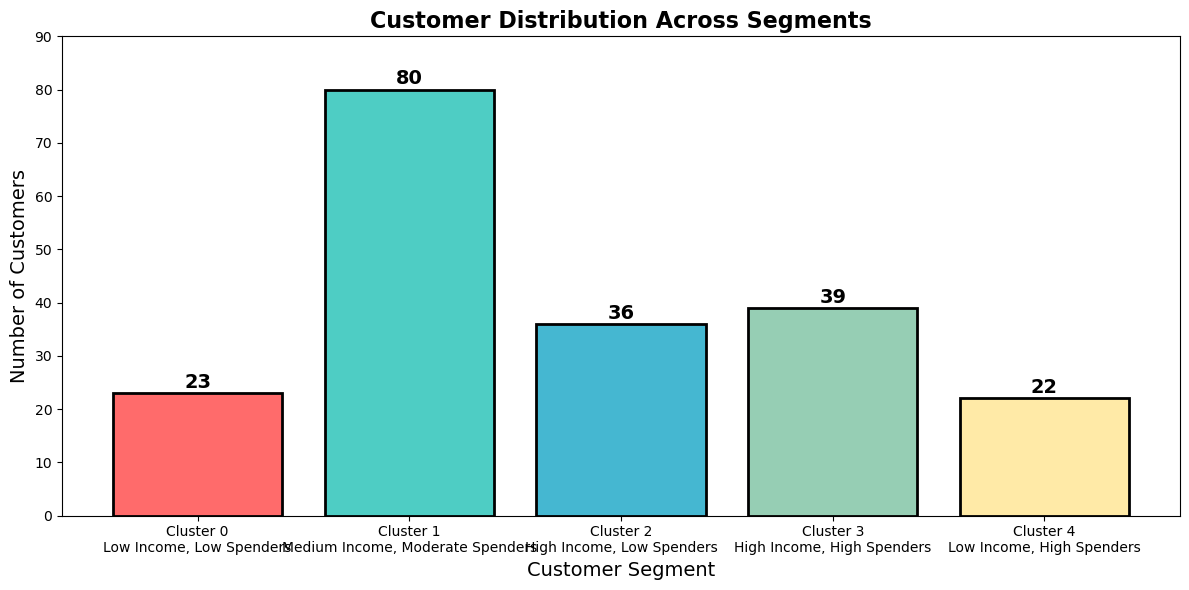

In [232]:
# Create a summary chart showing segment sizes
plt.figure(figsize=(12, 6))

segment_counts = df['Cluster'].value_counts().sort_index()

bars = plt.bar(range(K), segment_counts.values, color=cluster_colors, edgecolor='black', linewidth=2)

# Add count labels on bars
for bar, count in zip(bars, segment_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{count}', ha='center', fontsize=14, fontweight='bold')

# Create labels for x-axis
labels = [f"Cluster {i}\n{segment_names[i]}" for i in range(K)]
plt.xticks(range(K), labels, fontsize=10)

plt.xlabel('Customer Segment', fontsize=14)
plt.ylabel('Number of Customers', fontsize=14)
plt.title('Customer Distribution Across Segments', fontsize=16, fontweight='bold')
plt.ylim(0, max(segment_counts.values) + 10)

plt.tight_layout()
plt.show()

---

# PART 10: Final Summary

In [235]:
print("\n" + "="*70)
print("              PROJECT SUMMARY")
print("="*70)

print("\n📊 DATA:")
print(f"   • Total customers analyzed: {len(df)}")
print(f"   • Features used: Annual Income, Spending Score")

print("\n🔬 METHOD:")
print(f"   • Algorithm: K-Means Clustering")
print(f"   • Optimal K found using: Elbow Method + Silhouette Score")
print(f"   • Number of clusters: {K}")
print(f"   • Silhouette Score: {silhouette_score(X_scaled, cluster_labels):.3f}")

print("\n👥 SEGMENTS DISCOVERED:")
for cluster in range(K):
    count = len(df[df['Cluster'] == cluster])
    pct = count / len(df) * 100
    print(f"   • {segment_names[cluster]}: {count} customers ({pct:.1f}%)")

print("\n✅ KEY INSIGHTS:")
print("   • Customers naturally form 5 distinct groups")
print("   • Each segment requires different marketing strategy")
print("   • VIP customers (High Income + High Spending) are most valuable")
print("   • Potential exists to convert High Income, Low Spenders")

print("\n" + "="*70)


              PROJECT SUMMARY

📊 DATA:
   • Total customers analyzed: 200
   • Features used: Annual Income, Spending Score

🔬 METHOD:
   • Algorithm: K-Means Clustering
   • Optimal K found using: Elbow Method + Silhouette Score
   • Number of clusters: 5
   • Silhouette Score: 0.544

👥 SEGMENTS DISCOVERED:
   • Low Income, Low Spenders: 23 customers (11.5%)
   • Medium Income, Moderate Spenders: 80 customers (40.0%)
   • High Income, Low Spenders: 36 customers (18.0%)
   • High Income, High Spenders: 39 customers (19.5%)
   • Low Income, High Spenders: 22 customers (11.0%)

✅ KEY INSIGHTS:
   • Customers naturally form 5 distinct groups
   • Each segment requires different marketing strategy
   • VIP customers (High Income + High Spending) are most valuable
   • Potential exists to convert High Income, Low Spenders



In [237]:
# Save the segmented data
output_df = df[['CustomerID', 'Age', 'Annual_Income_k', 'Spending_Score', 'Cluster', 'Segment_Name']]
print("\nFinal segmented customer data:")
output_df.head(20)


Final segmented customer data:


,CustomerID,Age,Annual_Income_k,Spending_Score,Cluster,Segment_Name
0,1,19,15,39,0,"Low Income, Low Spenders"
1,2,21,15,81,4,"Low Income, High Spenders"
2,3,20,16,6,0,"Low Income, Low Spenders"
3,4,23,16,77,4,"Low Income, High Spenders"
4,5,31,17,40,0,"Low Income, Low Spenders"
5,6,22,17,76,4,"Low Income, High Spenders"
6,7,35,18,6,0,"Low Income, Low Spenders"
7,8,23,18,94,4,"Low Income, High Spenders"
8,9,64,19,3,0,"Low Income, Low Spenders"
9,10,30,19,72,4,"Low Income, High Spenders"


---

# 🎉 Congratulations!

You have completed an **end-to-end customer segmentation project**!

## What You Learned:

- ✅ Load and explore customer data
- ✅ Create visualizations with matplotlib and seaborn
- ✅ Scale data using StandardScaler
- ✅ Find optimal K using Elbow and Silhouette methods
- ✅ Apply K-Means clustering
- ✅ Visualize clusters with scatter plots and PCA
- ✅ Analyze and name customer segments
- ✅ Create actionable business recommendations

## This is Real Data Science!

Companies like **Amazon**, **Netflix**, **Spotify**, and **banks** use exactly this workflow to segment their customers and personalize marketing.

---

## Next Steps:

1. Try clustering with 3 features (add Age)
2. Experiment with different K values
3. Try other clustering algorithms (DBSCAN, Hierarchical)
4. Apply to your own datasets!